## SetUp File

In [ ]:
# ============================================
# SETUP: UPLOAD FILE
# ============================================
from google.colab import files
uploaded = files.upload()  # pilih file Data_Tanaman_Padi_Sumatera_version_1.csv

Saving Data_Tanaman_Padi_Sumatera_version_1.csv to Data_Tanaman_Padi_Sumatera_version_1 (2).csv


##Library (Python)

In [ ]:
# ============================================
# IMPORT LIBRARY
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

##Data

In [ ]:
# ============================================
# LOAD DATA
# ============================================
df = pd.read_csv('Data_Tanaman_Padi_Sumatera_version_1.csv', encoding='utf-8-sig')

kolom_numerik = ['Produksi', 'Luas Panen', 'Curah hujan', 'Kelembapan', 'Suhu rata-rata']

print(f"Jumlah baris     : {len(df)}")
print(f"Jumlah provinsi  : {df['Provinsi'].nunique()}")
print(f"Daftar provinsi  : {sorted(df['Provinsi'].unique())}")
print()

Jumlah baris     : 224
Jumlah provinsi  : 8
Daftar provinsi  : ['Aceh', 'Bengkulu', 'Jambi', 'Lampung', 'Riau', 'Sumatera Barat', 'Sumatera Selatan', 'Sumatera Utara']



## Statistika Deskriptif

In [ ]:
# ============================================
# 1. UKURAN PEMUSATAN & PENYEBARAN (Tabel Lengkap)
# ============================================
hasil = pd.DataFrame({
    'Mean': df[kolom_numerik].mean(),
    'Median': df[kolom_numerik].median(),
    'Modus': [df[c].mode().values[0] for c in kolom_numerik],
    'Range': df[kolom_numerik].max() - df[kolom_numerik].min(),
    'Variance': df[kolom_numerik].var(),
    'Std Dev': df[kolom_numerik].std(),
    'IQR': df[kolom_numerik].quantile(0.75) - df[kolom_numerik].quantile(0.25),
}).round(2)

print("=" * 80)
print("UKURAN PEMUSATAN & PENYEBARAN DATA")
print("=" * 80)
print(hasil.to_string())

# ============================================
# 2. RINGKASAN STATISTIK CEPAT (describe)
# ============================================
print("\n" + "=" * 80)
print("RINGKASAN STATISTIK (describe)")
print("=" * 80)
print(df[kolom_numerik].describe().round(2).to_string())

UKURAN PEMUSATAN & PENYEBARAN DATA
                      Mean      Median     Modus       Range      Variance     Std Dev         IQR
Produksi        1679700.89  1667773.00  42938.00  4838151.00  1.348821e+12  1161387.39  1887993.75
Luas Panen       374349.97   373551.50  63142.04   809594.96  5.417310e+10   232751.16   367650.75
Curah hujan        2452.49     2315.70   2364.70     5299.50  1.064968e+06     1031.97     1336.17
Kelembapan           80.95       82.38     84.00       36.40  2.380000e+01        4.88        5.03
Suhu rata-rata       26.80       26.73     27.10        7.66  1.430000e+00        1.20        1.02

RINGKASAN STATISTIK (describe)
         Produksi  Luas Panen  Curah hujan  Kelembapan  Suhu rata-rata
count      224.00      224.00       224.00      224.00          224.00
mean   1679700.89   374349.97      2452.49       80.95           26.80
std    1161387.39   232751.16      1031.97        4.88            1.20
min      42938.00    63142.04       222.50       54.20 

## Visualisasi Data

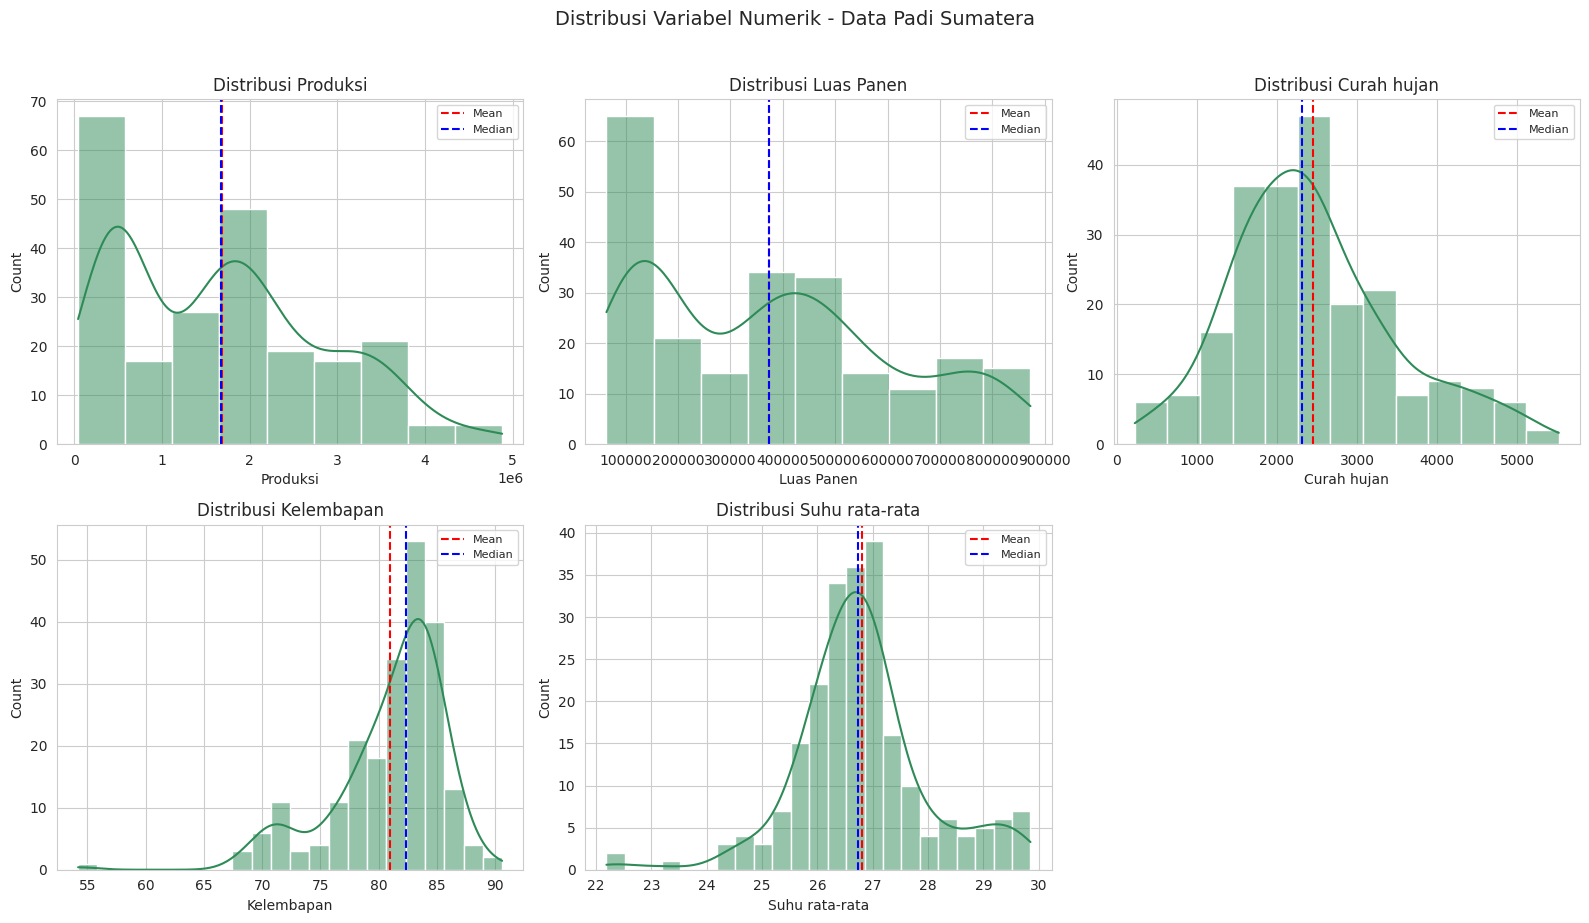

In [ ]:
# ============================================
# 1. VISUALISASI A: DISTRIBUSI (Histogram tiap variabel)
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(kolom_numerik):
    sns.histplot(df[col], kde=True, ax=axes[i], color='seagreen')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df[col].median(), color='blue', linestyle='--', label='Median')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].legend(fontsize=8)
axes[-1].axis('off')
plt.suptitle('Distribusi Variabel Numerik - Data Padi Sumatera', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('distribusi_variabel.png', dpi=150, bbox_inches='tight')
plt.show()

##Visualisasi (BoxPlot)

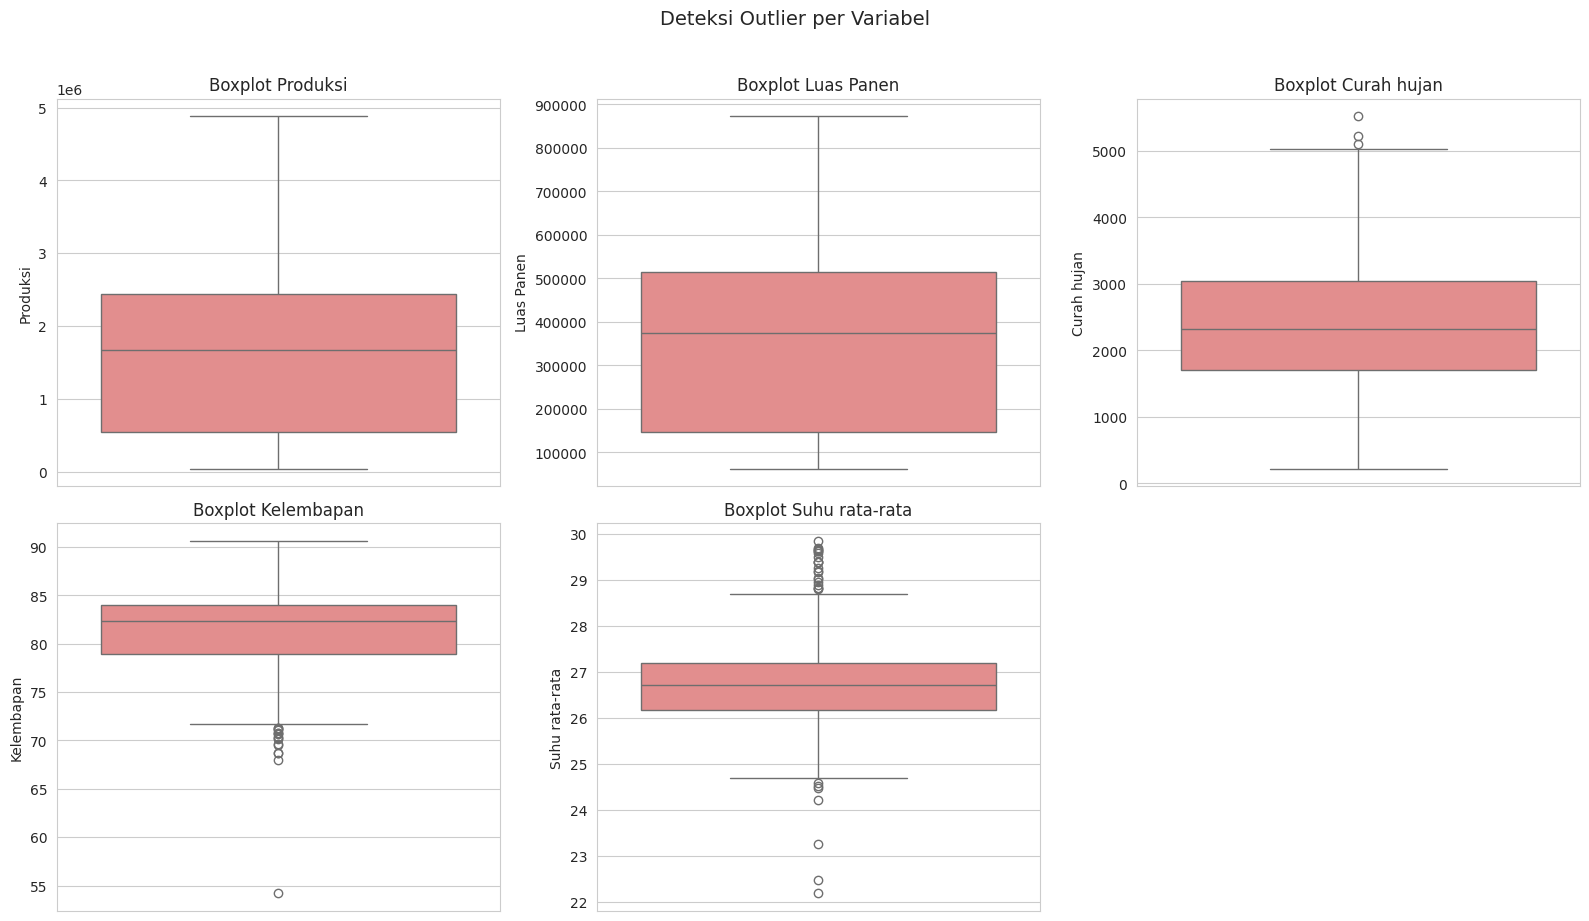

In [ ]:
# ============================================
# 2. VISUALISASI B: BOXPLOT (Deteksi Outlier)
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(kolom_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot {col}')
axes[-1].axis('off')
plt.suptitle('Deteksi Outlier per Variabel', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('boxplot_variabel.png', dpi=150, bbox_inches='tight')
plt.show()

##Visualisasi (Perbandingan Antar Provinsi)

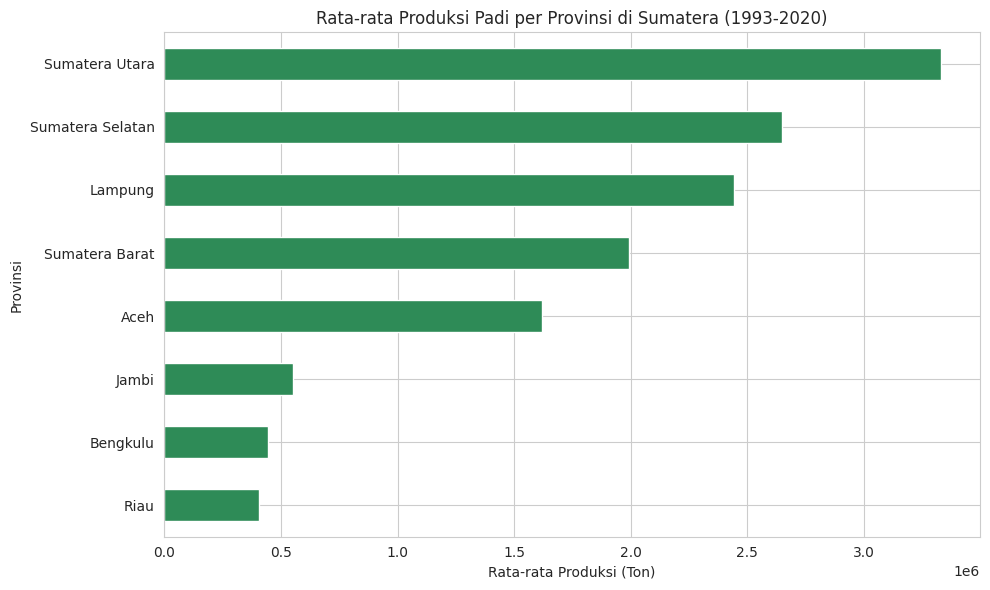


Rata-rata Produksi per Provinsi (Tertinggi → Terendah):
Provinsi
Sumatera Utara      3330471.0
Sumatera Selatan    2648643.0
Lampung             2444068.0
Sumatera Barat      1990396.0
Aceh                1618737.0
Jambi                552864.0
Bengkulu             444965.0
Riau                 407465.0


In [ ]:
# ============================================
# 3. VISUALISASI C: PERBANDINGAN ANTAR PROVINSI
# ============================================
rata_provinsi = df.groupby('Provinsi')['Produksi'].mean().sort_values()

plt.figure(figsize=(10, 6))
rata_provinsi.plot(kind='barh', color='seagreen')
plt.xlabel('Rata-rata Produksi (Ton)')
plt.title('Rata-rata Produksi Padi per Provinsi di Sumatera (1993-2020)')
plt.tight_layout()
plt.savefig('produksi_per_provinsi.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRata-rata Produksi per Provinsi (Tertinggi → Terendah):")
print(rata_provinsi.sort_values(ascending=False).round(0).to_string())

##Visualisasi (HeatMap)

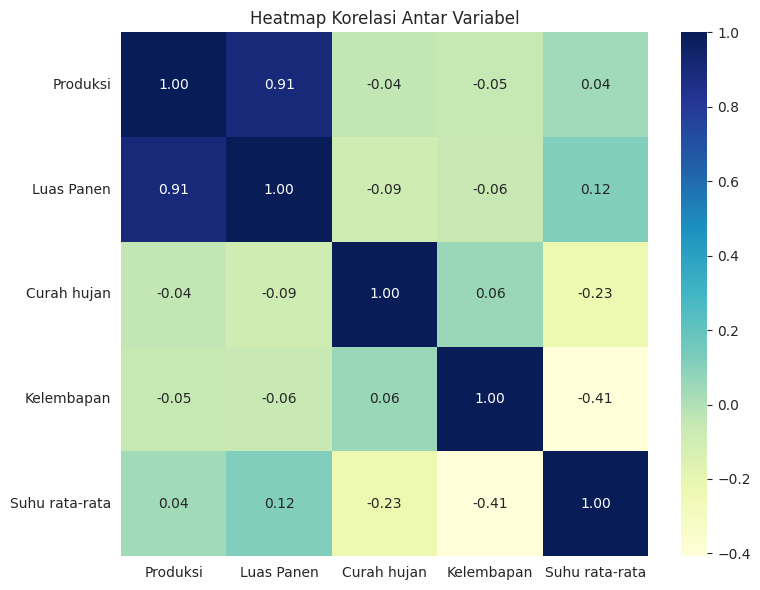

In [ ]:
# ============================================
# 4. VISUALISASI D: HEATMAP KORELASI
# ============================================
plt.figure(figsize=(8, 6))
sns.heatmap(df[kolom_numerik].corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Heatmap Korelasi Antar Variabel')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

## Analisis Hipotesis

In [ ]:
from scipy import stats

# ============================================
# 1. HIPOTESIS FORMAL (H1 - H4)
# ============================================
print("=" * 60)
print("HIPOTESIS PENELITIAN")
print("=" * 60)
hipotesis = {
    "H1": ("Luas Panen",     "Luas panen TIDAK berhubungan dengan produksi padi",     "Luas panen BERHUBUNGAN dengan produksi padi"),
    "H2": ("Curah hujan",    "Curah hujan TIDAK berhubungan dengan produksi padi",     "Curah hujan BERHUBUNGAN dengan produksi padi"),
    "H3": ("Kelembapan",     "Kelembapan TIDAK berhubungan dengan produksi padi",      "Kelembapan BERHUBUNGAN dengan produksi padi"),
    "H4": ("Suhu rata-rata", "Suhu rata-rata TIDAK berhubungan dengan produksi padi", "Suhu rata-rata BERHUBUNGAN dengan produksi padi"),
}
for key, (var, h0, h1) in hipotesis.items():
    print(f"\n{key} - {var}")
    print(f"  H0: {h0}")
    print(f"  H1: {h1}")

HIPOTESIS PENELITIAN

H1 - Luas Panen
  H0: Luas panen TIDAK berhubungan dengan produksi padi
  H1: Luas panen BERHUBUNGAN dengan produksi padi

H2 - Curah hujan
  H0: Curah hujan TIDAK berhubungan dengan produksi padi
  H1: Curah hujan BERHUBUNGAN dengan produksi padi

H3 - Kelembapan
  H0: Kelembapan TIDAK berhubungan dengan produksi padi
  H1: Kelembapan BERHUBUNGAN dengan produksi padi

H4 - Suhu rata-rata
  H0: Suhu rata-rata TIDAK berhubungan dengan produksi padi
  H1: Suhu rata-rata BERHUBUNGAN dengan produksi padi


##Uji Normalitas (Shapiro-Wilk)

In [ ]:
# ============================================
# 2. UJI NORMALITAS (Shapiro-Wilk)
# ============================================
print("\n" + "=" * 60)
print("UJI NORMALITAS - SHAPIRO WILK")
print("=" * 60)
print(f"{'Variabel':<20} {'W':>8} {'p-value':>12} {'Hasil':>15}")
print("-" * 60)
for col in kolom_numerik:
    stat, p = stats.shapiro(df[col])
    hasil = "Normal ✅" if p > 0.05 else "Tidak Normal ❌"
    print(f"{col:<20} {stat:>8.4f} {p:>12.6f} {hasil:>15}")
print()
print("Kesimpulan: Semua variabel TIDAK NORMAL (p < 0.05)")
print("→ Menggunakan Korelasi SPEARMAN (bukan Pearson)")


UJI NORMALITAS - SHAPIRO WILK
Variabel                    W      p-value           Hasil
------------------------------------------------------------
Produksi               0.9201     0.000000  Tidak Normal ❌
Luas Panen             0.9192     0.000000  Tidak Normal ❌
Curah hujan            0.9669     0.000044  Tidak Normal ❌
Kelembapan             0.8875     0.000000  Tidak Normal ❌
Suhu rata-rata         0.9424     0.000000  Tidak Normal ❌

Kesimpulan: Semua variabel TIDAK NORMAL (p < 0.05)
→ Menggunakan Korelasi SPEARMAN (bukan Pearson)


##Korelasi Spearman

In [ ]:
# ============================================
# 3. KORELASI SPEARMAN + KEPUTUSAN H0/H1
# ============================================
print("\n" + "=" * 60)
print("UJI KORELASI SPEARMAN (α = 0.05)")
print("=" * 60)
print(f"{'Hipotesis':<6} {'Variabel':<20} {'rho':>8} {'p-value':>12} {'Kekuatan':>15} {'Keputusan'}")
print("-" * 90)

def kekuatan(r):
    r = abs(r)
    if r >= 0.8:   return "Sangat Kuat"
    elif r >= 0.6: return "Kuat"
    elif r >= 0.4: return "Sedang"
    elif r >= 0.2: return "Lemah"
    else:          return "Sangat Lemah"

hasil_korelasi = {}
for (key, (var, h0, h1)) in hipotesis.items():
    rho, p = stats.spearmanr(df[var], df['Produksi'])
    keputusan = "Tolak H0 ✅" if p < 0.05 else "Gagal Tolak H0 ❌"
    kuat = kekuatan(rho)
    hasil_korelasi[var] = (rho, p)
    print(f"{key:<6} {var:<20} {rho:>8.4f} {p:>12.6f} {kuat:>15} {keputusan}")


UJI KORELASI SPEARMAN (α = 0.05)
Hipotesis Variabel                  rho      p-value        Kekuatan Keputusan
------------------------------------------------------------------------------------------
H1     Luas Panen             0.9201     0.000000     Sangat Kuat Tolak H0 ✅
H2     Curah hujan           -0.0674     0.315579    Sangat Lemah Gagal Tolak H0 ❌
H3     Kelembapan            -0.1364     0.041468    Sangat Lemah Tolak H0 ✅
H4     Suhu rata-rata         0.1269     0.057959    Sangat Lemah Gagal Tolak H0 ❌


## Visualisasi Korelasi (Scatter Plot)

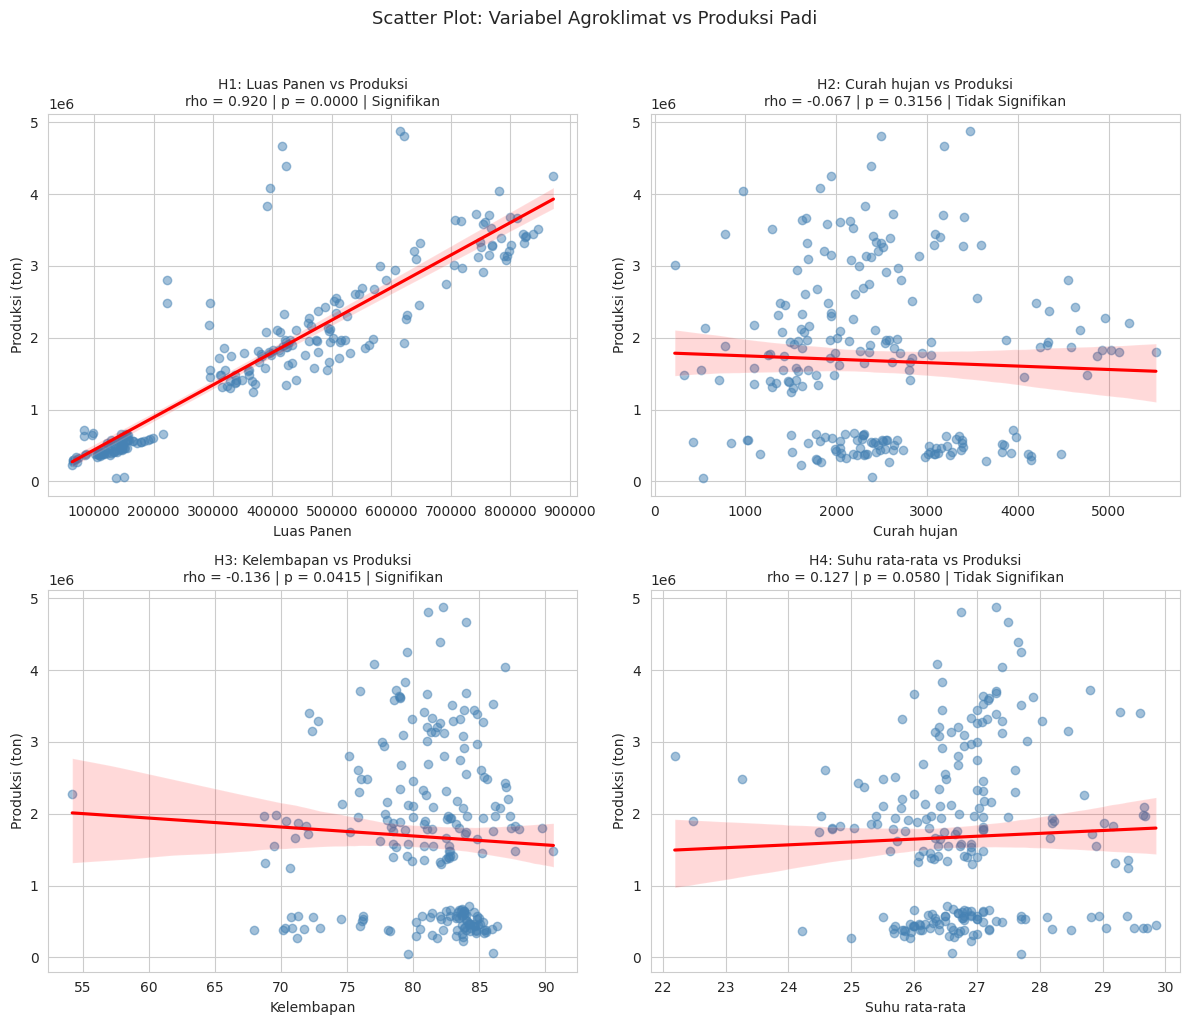

In [ ]:
# ============================================
# SCATTER PLOT (4 variabel vs Produksi)
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
vars_x = ['Luas Panen', 'Curah hujan', 'Kelembapan', 'Suhu rata-rata']
labels_h = ['H1', 'H2', 'H3', 'H4']
for i, col in enumerate(vars_x):
    rho, p = hasil_korelasi[col]
    sig_label = "Signifikan" if p < 0.05 else "Tidak Signifikan"
    sns.regplot(x=df[col], y=df['Produksi'], ax=axes[i],
                scatter_kws={'alpha': 0.5, 'color': 'steelblue'},
                line_kws={'color': 'red'})
    axes[i].set_title(
        f'{labels_h[i]}: {col} vs Produksi\n'
        f'rho = {rho:.3f} | p = {p:.4f} | {sig_label}',
        fontsize=10
    )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Produksi (ton)')
plt.suptitle('Scatter Plot: Variabel Agroklimat vs Produksi Padi', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('scatter_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

##Interpretasi

In [ ]:
# ============================================
# RINGKASAN KEPUTUSAN HIPOTESIS
# ============================================
print()
print("=" * 60)
print("RINGKASAN KEPUTUSAN HIPOTESIS")
print("=" * 60)

ringkasan_data = []
for (key, (var, h0, h1)) in hipotesis.items():
    rho, p = hasil_korelasi[var]

    keputusan_h0_str = ""
    keputusan_verbal = ""

    if p < 0.05:
        keputusan_h0_str = "TOLAK H0"
        keputusan_verbal = f"{h1}. Terdapat bukti statistik yang kuat untuk mendukung hipotesis alternatif."
    else:
        keputusan_h0_str = "GAGAL TOLAK H0"
        keputusan_verbal = f"{h0}. Tidak cukup bukti statistik untuk menolak hipotesis nol."

    ringkasan_data.append({
        "Hipotesis": key,
        "Variabel": var,
        "Keputusan H0": keputusan_h0_str,
        "Rho (Spearman)": f"{rho:.3f}",
        "P-value": f"{p:.4f}",
        "Keputusan Verbal": keputusan_verbal
    })

ringkasan_df = pd.DataFrame(ringkasan_data)
display(ringkasan_df)


RINGKASAN KEPUTUSAN HIPOTESIS


,Hipotesis,Variabel,Keputusan H0,Rho (Spearman),P-value,Keputusan Verbal
0,H1,Luas Panen,TOLAK H0,0.920,0.0000,Luas panen BERHUBUNGAN dengan produksi padi. T...
1,H2,Curah hujan,GAGAL TOLAK H0,-0.067,0.3156,Curah hujan TIDAK berhubungan dengan produksi ...
2,H3,Kelembapan,TOLAK H0,-0.136,0.0415,Kelembapan BERHUBUNGAN dengan produksi padi. T...
3,H4,Suhu rata-rata,GAGAL TOLAK H0,0.127,0.0580,Suhu rata-rata TIDAK berhubungan dengan produk...
